# USGS 3DEP LiDAR Explorer                                                                                                                                      
Explore high-resolution airborne LiDAR point clouds collected by the U.S. Geological Survey's 3D Elevation Program (3DEP). Each LiDAR dataset captures the height of the ground, vegetation, and structures over a region by recording millions to billions of laser returns from aircraft. This notebook lets you pick a region of interest, download the point cloud, and turn it into a 1-meter digital elevation model (DEM) with hillshade.  
                                                        
The workflow runs in five steps:

1. **Pick an area** — draw a rectangle on the USGS 3DEP coverage map and select a dataset that intersects it from the auto-populated dropdown                            
2. **Download the point cloud** — fetch the LiDAR returns for the selected area from the public Entwine Point Tile (EPT) service
3. **Inspect the point cloud** — point count, elevation range, classification breakdown, and a 3D preview colored by elevation                                           
4. **Generate a DEM and hillshade** — rasterize the ground returns into a 1-meter DEM, then build a shaded relief view                                                   
5. **Visualize** — overlay the locally-computed hillshade against the USGS 3DEP WMS service for wider context

Linked widgets in step 1 are powered by the `sage-bbox-map` and `sage-dropdown` UI skills, which subscribe to changes in kernel variables (`USER_BBOX` triggers the dataset filter automatically when you draw a rectangle). The `usgs-lidar` data skill provides only the data primitives — `fetch_coverage()` and `filter_by_bbox()` — and knows nothing about the UI.                                    
                                                        
No coding needed — just run each cell and follow the prompts.  

In [ ]:
%reset

In [2]:
%%ask                                                                                                                                                                    
Create a USGS 3DEP coverage map with a bounding box selection tool. 
Show a dropdown of USGS 3DEP datasets that intersect the bounding box 
with under 20 million points.

I'll help you create a USGS 3DEP coverage map with bounding box selection and a filtered dropdown of datasets. Let me start by checking the USGS LiDAR skill for the proper workflow.

I'll create a script that shows the USGS 3DEP coverage map with bounding box selection and a reactive dropdown that filters datasets under 20 million points. The skill provides a complete script example I can use directly.

⟳ Interactive widget — re-run this cell to restore map interactivity.
 Widget callbacks live in the kernel and are lost when the notebook is closed.

Make this Notebook Trusted to load map: File -> Trust Notebook <iframe srcdoc="<!DOCTYPE html>
<html>
<head>
 
 <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
 <script src="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.js"></script>
 <script src="https://code.jquery.com/jquery-3.7.1.min.js"></script>
 <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/js/bootstrap.bundle.min.js"></script>
 <script src="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.js"></script>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/css/bootstrap.min.css"/>
 <link rel="stylesheet" href="https://netdna.bootstrapcdn.com/bootstrap/3.0.0/css/bootstrap-glyphicons.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@fortawesome/fontawesome-free@6.2.0/css/all.min.css"/>
 <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/gh/python-visualization/folium/folium/templates/leaflet.awesome.rotate.min.css"/>
 
 <meta name="viewport" content="width=device-width,
 initial-scale=1.0, maximum-scale=1.0, user-scalable=no" />
 <style>
 #map_ee8b13bdf44d54bab35a06d9c8bba22e {
 position: relative;
 width: 100.0%;
 height: 450.0px;
 left: 0.0%;
 top: 0.0%;
 }
 .leaflet-container { font-size: 1rem; }
 </style>

 <style>html, body {
 width: 100%;
 height: 100%;
 margin: 0;
 padding: 0;
 }
 </style>

 <style>#map {
 position:absolute;
 top:0;
 bottom:0;
 right:0;
 left:0;
 }
 </style>

 <script>
 L_NO_TOUCH = false;
 L_DISABLE_3D = false;
 </script>

 
</head>
<body>
 
 
 <div class="folium-map" id="map_ee8b13bdf44d54bab35a06d9c8bba22e" ></div>
 
</body>
<script>
 
 
 var map_ee8b13bdf44d54bab35a06d9c8bba22e = L.map(
 "map_ee8b13bdf44d54bab35a06d9c8bba22e",
 {
 center: [40.0, -100.0],
 crs: L.CRS.EPSG3857,
 ...{
 "zoom": 4,
 "zoomControl": true,
 "preferCanvas": false,
}

 }
 );

 

 
 
 var tile_layer_ccd5af7422827267b373b3ed20ac33ff = L.tileLayer(
 "https://tile.openstreetmap.org/{z}/{x}/{y}.png",
 {
 "minZoom": 0,
 "maxZoom": 19,
 "maxNativeZoom": 19,
 "noWrap": false,
 "attribution": "\u0026copy; \u003ca href=\"https://www.openstreetmap.org/copyright\"\u003eOpenStreetMap\u003c/a\u003e contributors",
 "subdomains": "abc",
 "detectRetina": false,
 "tms": false,
 "opacity": 1,
}

 );
 
 
 tile_layer_ccd5af7422827267b373b3ed20ac33ff.addTo(map_ee8b13bdf44d54bab35a06d9c8bba22e);
 
 
 function geo_json_6d076cec4523acf573158a79d307fd0f_styler(feature) {
 switch(feature.id) {
 case "0": case "27": case "67": case "85": case "96": case "99": case "108": case "131": case "134": case "159": case "182": case "198": case "201": case "255": case "274": case "310": case "311": case "336": case "419": case "449": case "473": case "480": case "489": case "575": case "659": case "677": case "699": case "709": case "754": case "760": case "841": case "870": case "873": case "919": case "940": case "949": case "958": case "1013": case "1084": case "1106": case "1142": case "1173": case "1182": case "1236": case "1242": case "1287": case "1301": case "1318": case "1391": case "1408": case "1418": case "1425": case "1434": case "1443": case "1480": case "1497": case "1538": case "1550": case "1552": case "1553": case "1616": case "1628": case "1630": case "1635": case "1661": case "1680": case "1692": case "1693": case "1766": case "1786": case "1803": case "1804": case "1885": case "1910": case "2007": case "2040": case "2050": case "2063": case "2067": case "2077": case "2078": case "2081": case "2088": case "2106": case "2121": case "2137": case "2159": case "2160": case "2181": case "2192": case "2204": 
 return {"color": "#4daf4a", "fillColor": "#4daf4a", "fillOpacity": 0.3, "opacity": 0.8, "weight": 1};
 case "1": case "9": case "48

⟳ Interactive widget — re-run this cell to restore dropdown interactivity.
 Widget callbacks live in the kernel and are lost when the notebook is closed.

## USGS 3DEP Coverage Map and Dataset Selector

I've created an interactive USGS 3DEP coverage viewer with the following components:

**Interactive Map** - Displays all available USGS 3DEP LiDAR datasets across the United States. You can draw a rectangle on this map to select an area of interest.

**Reactive Dropdown** - Automatically populates with USGS 3DEP datasets that intersect your selected bounding box and have under 20 million estimated points. The dropdown shows each dataset with its estimated point count.

**Kernel Variables Set** - When you select a dataset from the dropdown, these variables become available:
- `USER_BBOX` - The bounding box coordinates you drew (EPSG:4326)
- `USER_EPT_URL` - The EPT endpoint URL for the selected dataset
- `USER_DATASET_NAME` - The name of the selected dataset

**How to Use** :
1. Draw a rectangle on the coverage map to select your area of interest
2. Wait a moment for the dropdown to populate (it reacts automatically)
3. Select a dataset from the dropdown to set the kernel variables for subsequent analysis

The map and dropdown work together - the dropdown only shows datasets that both cover your selected area and have under 20 million points, ensuring manageable downloads for processing.

I'll download the USGS 3DEP point cloud for the selected bounding box and analyze it. Let me start by reading the USGS-LIDAR skill to understand the proper workflow.

I'll download the USGS 3DEP point cloud for the selected area and analyze it. The bounding box is in Nevada and the selected dataset is NV_WestCentralEarthMRI_2_2020.

Let me create a script to download the point cloud and generate the analysis:

Excellent! The point cloud has been downloaded successfully. Let me read the statistics file to get the complete data:

## USGS 3DEP Point Cloud Analysis

Successfully downloaded and analyzed the USGS 3DEP LiDAR point cloud for the selected area in west-central Nevada.

### Dataset Information

**Dataset** : NV_WestCentralEarthMRI_2_2020  
**EPT URL** : https://s3-us-west-2.amazonaws.com/usgs-lidar-public/NV_WestCentralEarthMRI_2_2020/ept.json  
**Coordinate System** : EPSG:3857 (Web Mercator)

### Bounding Box

**WGS84 (lat/lon)** : 
- Min: (-117.767086, 39.703878)
- Max: (-117.760048, 39.707708)

**Projected (EPSG:3857, meters)** :
- X: -13,109,772.05 to -13,108,988.58
- Y: 4,823,003.49 to 4,823,557.67

### Point Cloud Summary

**Total points** : 2,027,119

### Elevation Statistics

**Elevation range** : 2,105.98 to 2,431.83 m  
**Mean elevation** : 2,272.01 m  
**Standard deviation** : 73.93 m

The area spans an elevation difference of approximately 326 meters, which is characteristic of the mountainous terrain in this region of Nevada.

### Classification Breakdown

| LAS Class | Description | Points | Percentage |
|-----------|-------------|--------|------------|
| 2 | Ground | 1,469,370 | 72.49% |
| 1 | Unclassified | 556,371 | 27.45% |
| 7 | Low point (noise) | 1,376 | 0.07% |
| 18 | High noise | 2 | 0.00% |

The point cloud is dominated by ground returns (72.49%), which is typical for LiDAR data collected over natural terrain. The remaining 27.45% are unclassified points that could represent vegetation, buildings, or other features not specifically classified during processing. Noise points are minimal (0.07%), indicating good data quality.


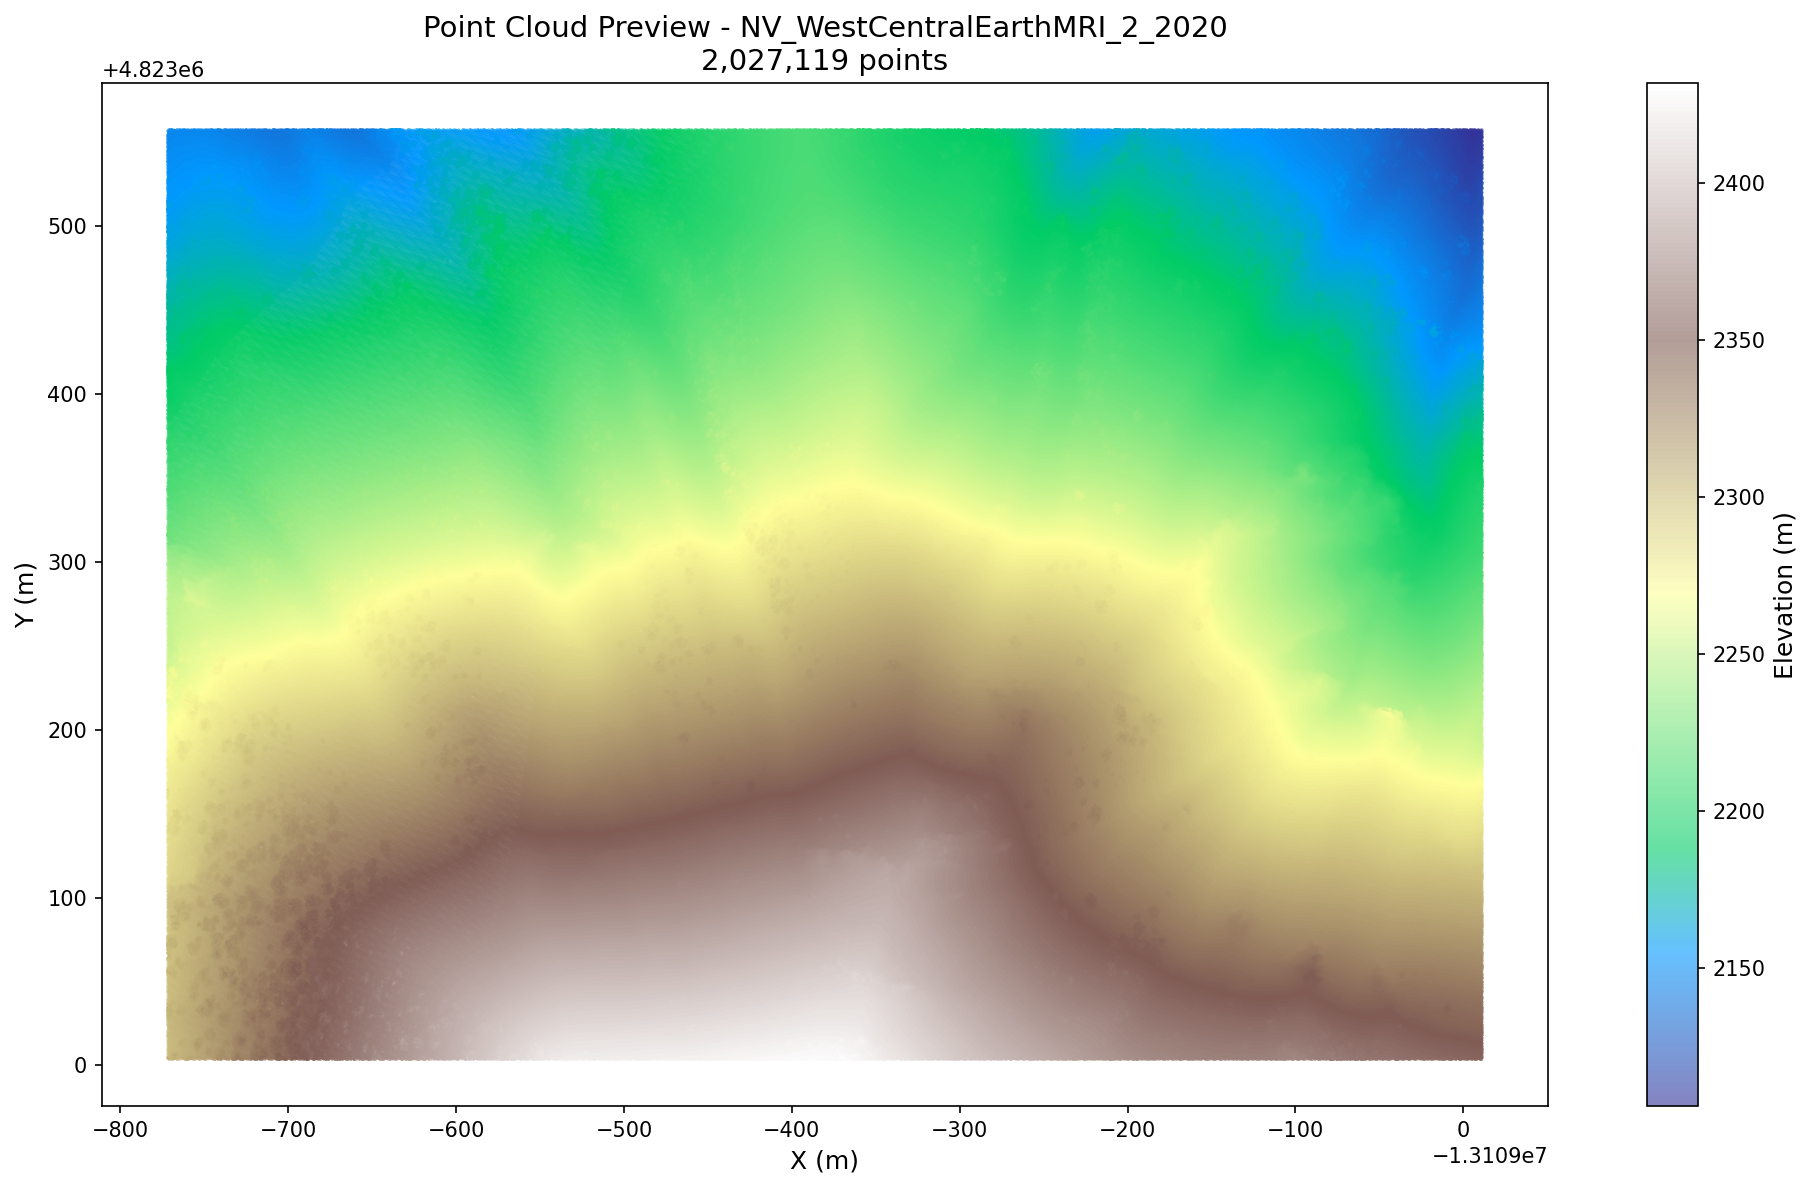

The preview image shows the point cloud colored by elevation using a terrain colormap. The color gradient from green to brown represents the elevation range from approximately 2,106 m (green/lower) to 2,432 m (brown/higher), clearly showing the topographic variation across the selected area.

In [3]:
%%ask                                                                                                                                                                    
Download the USGS 3DEP point cloud for the selected bounding box
and show point count, elevation range, classification breakdown,                                                                                                         
and a preview image of the point cloud colored by elevation.

I'll generate a 1-meter DEM from the ground points and create a hillshade visualization. Let me first check the USGS LiDAR skill for the proper workflow.

Now I'll create a script to generate a 1-meter DEM from ground points and create a hillshade visualization.

Now I'll create a visualization script to display the hillshade image.

## 1-Meter Digital Elevation Model - Hillshade

Successfully generated a 1-meter resolution DEM from the ground-classified LiDAR points and created a hillshade visualization.

### Processing Summary

**Ground points used** : 1,469,370 (LAS classification 2)  
**Grid size** : 785 x 556 meters (436,460 cells)  
**Grid coverage** : 97.3% of cells filled (424,840 of 436,460)  
**Coordinate system** : EPSG:3857 (Web Mercator)

### Elevation Statistics (Ground Points)

**Elevation range** : 2,105.98 to 2,429.74 m  
**Elevation span** : 323.76 m

### Hillshade Parameters

- **Azimuth** : 315° (northwest light source)
- **Altitude** : 45° (sun angle above horizon)
- **Resolution** : 1 meter


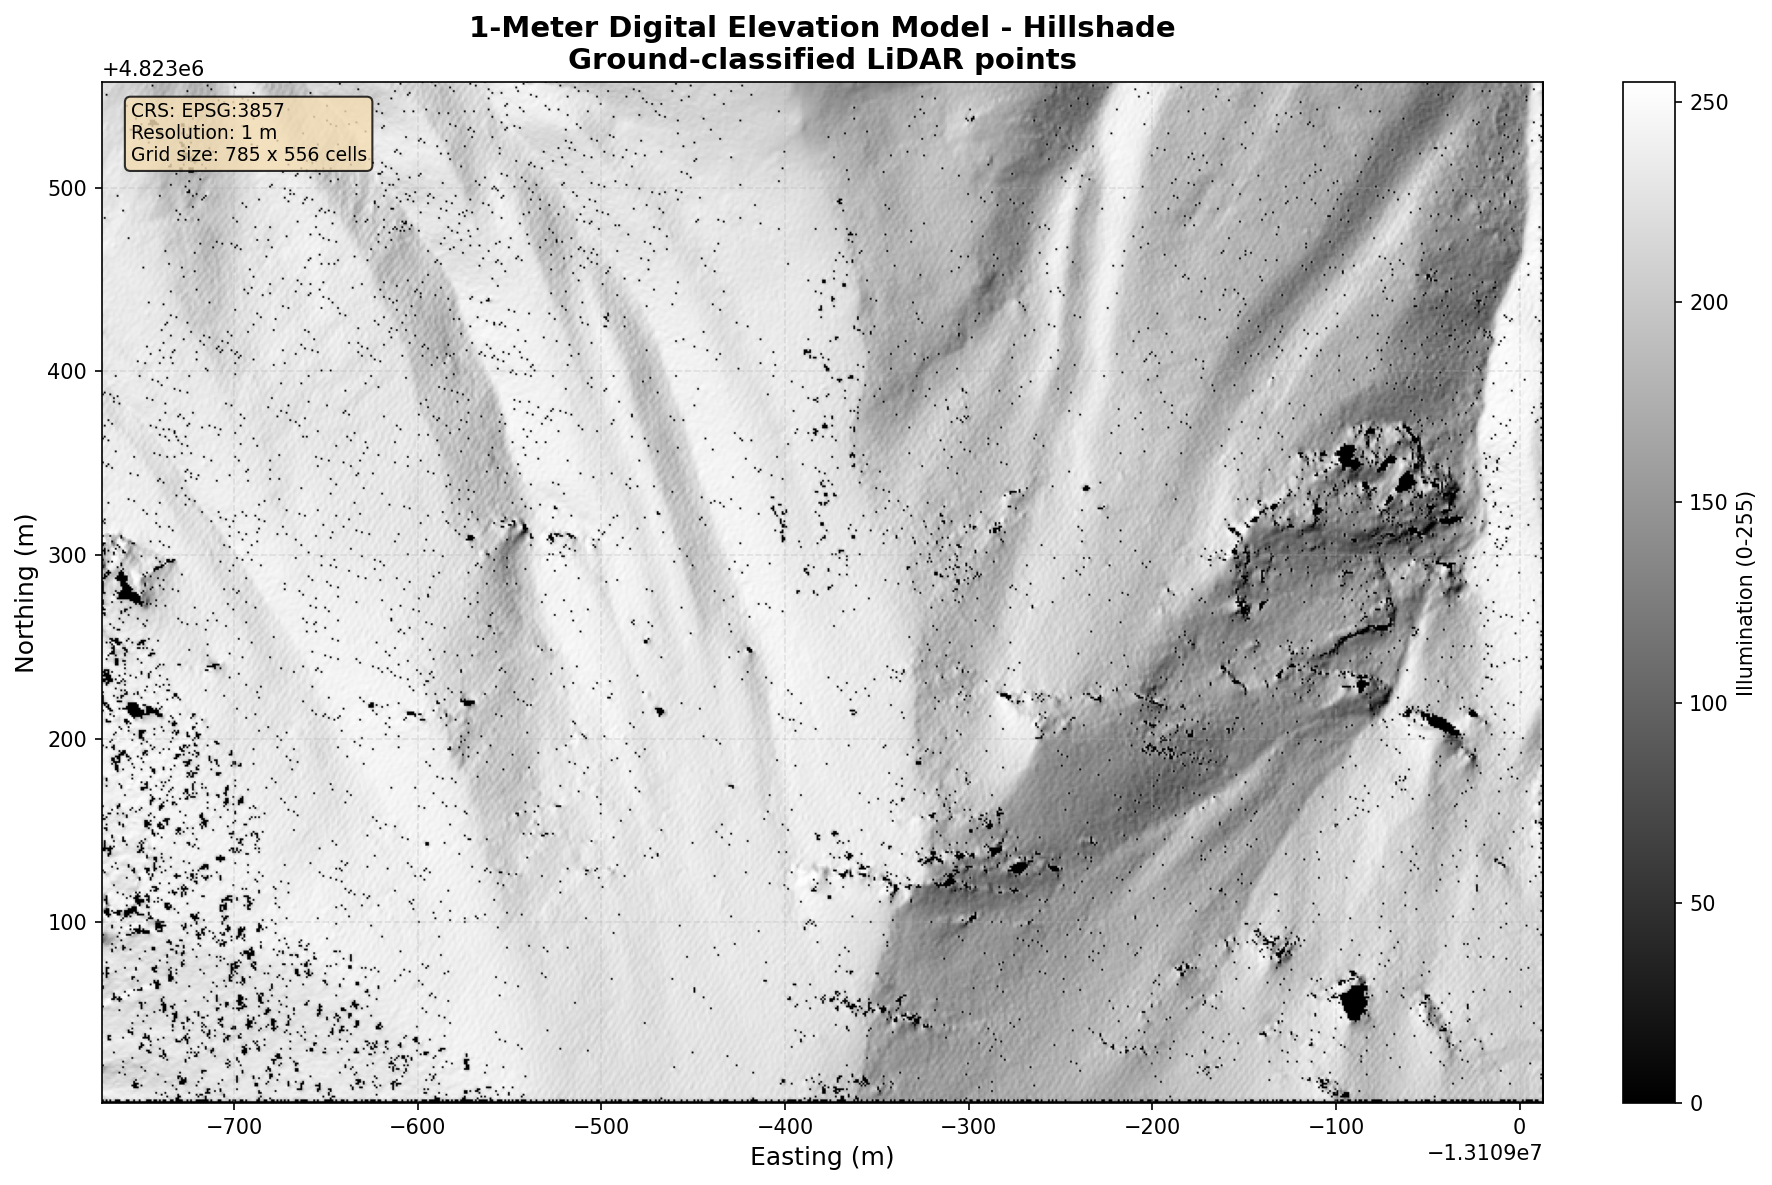

The hillshade visualization reveals the topographic structure of the area in west-central Nevada. The terrain shows significant relief with approximately 324 meters of elevation variation across the 785 x 556 meter area. The northwest illumination direction (azimuth 315°) creates shadows on north-facing slopes and highlights on south-facing slopes, accentuating the terrain's three-dimensional structure. The high grid coverage (97.3%) indicates dense ground point distribution, resulting in a complete and continuous DEM representation of the landscape.

In [5]:
%%ask                                                                                                                                                                    
Generate a 1-meter digital elevation model (DEM) from the ground-classified points, 
and visualize it as a hillshade image only.